## DATA ANALYSIS & VISUALISATION

--------------

This notebook contains reproducible analysis and visualisations for multiple film and streaming datasets. The sections below load data, import analysis functions, and produce charts for TMDb, box office, awards and streaming analysis.

Note: Use the project virtual environment (`venv`) and run `pip install -r requirements.txt` if needed.

In [1]:
# Standard library imports
from pathlib import Path
import sys
import platform

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import sys
import os

def load_dataset(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    return df

### Load Analysis Functions

Import reusable analysis functions from the `scripts` package. These functions contain the plotting and aggregation logic used in the notebook.

In [2]:
# Ensuring project root is on sys.path
sys.path.insert(0, str(Path('..').resolve()))

# Import analysis functions
# Netflix
from scripts.analysis import netflix_rev_subs, netflix_spend, netflix_top_movies, netflix_top_shows
# Box Office - The Numbers
from scripts.analysis import worldwide_box_office_trend_by_genre, top_5_genres_percentage_per_year, top_8_genres_percentage_per_year, movie_count_per_distributor_overtime_top8, worldwide_box_office_trend_by_distributor
# TMDB
from scripts.analysis import tmdb_top_1000, popular_genres_top_1000, main_production_companies_top_1000, top20_movies_by_average_vote
# Awards
from scripts.analysis import oscars_winners_table, oscars_winners, total_oscar_wins_per_genre, oscar_wins_top_genres_per_decade, prep_oscars_wins, total_oscar_wins_per_production_company, oscar_wins_top_companies_per_decade

print('Analysis functions imported')

c:\Users\SANZ7884\OneDrive\Documents\Film-TV-Data-Analysis\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Analysis functions imported


c:\Users\SANZ7884\OneDrive\Documents\Film-TV-Data-Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Datasets

Load cleaned datasets used across the notebook. Each dataset will be introduced under the Analysis section.

In [3]:
# TMDB
df_tmdb = load_dataset('../data/analysis_data/tmdb_top_movies.csv')
# Box Office - The Numbers
df_the_numbers = load_dataset('../data/analysis_data/cleaned_the_numbers.csv')
# Awards - Oscars
df_oscar_tmdb = load_dataset('../data/analysis_data/merged_oscar_tmdb.csv')
# Netflix
df_netflix_revenue_subs_spend = load_dataset('../data/analysis_data/cleaned_netflix_revenue_subs_spend.csv')
df_netflix_engagement = load_dataset('../data/analysis_data/cleaned_netflix_engagement.csv')

## Analysis

The analysis section follows: TMDb (ratings), Box Office (financial), Oscars (awards), and Netflix (streaming case study).

-----------------

### I. TMDB - Popular Movies Analysis

#### Overview

This section analyzes the most highly-rated and popular movies according to TMDb (The Movie Database). The analysis focuses on the **top 1000 movies by vote average**, filtered to films with at least 1000 votes to ensure statistical significance. We explore which **genres** and **production companies** are most represented in this elite subset of movies. Understanding these patterns reveals what audiences globally consider to be the highest-quality films across different time periods and creative categories.

#### Data

**Source:** [Kaggle - TMDB Movies Dataset](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/data)

**Coverage:** Movies released between 1980 and 2025 (930k+ movies in full dataset)

**Filtering Criteria:**
- Minimum 1,000 votes required (ensures reliable vote average)
- Top 1,000 movies ranked by vote average (the highest-rated films)
- Includes genres, production companies, vote counts, and audience ratings

#### Data Preparation & Methodology

For detailed information on how the TMDb dataset was loaded and cleaned, please refer to [load_data.py](../scripts/load_data.py).

**Key preparation steps:**
- **Duplicate handling:** Films with duplicate entries are deduplicated by ID and title, keeping the record with the highest vote count.
- **Filtering:** Only movies released from 1980 onward are included. Movies must have at least 1,000 votes to qualify.
- **Genre & Production Company flags:** Converted to binary columns (0 or 1) so a single film can contribute to multiple genres or companies, enabling comprehensive multi-category analysis.

In [4]:
# Load top 1000 movies by rating
df_tmdb_top_1000 = tmdb_top_1000(df_tmdb)

##### Most Popular Genres in Top 1000 Movies

Which genres are most common among the highest-rated movies? The chart below shows the number of top 1,000 films in each genre. Note that films with multiple genres are counted in each - e.g. a drama-action film contributes to both categories.

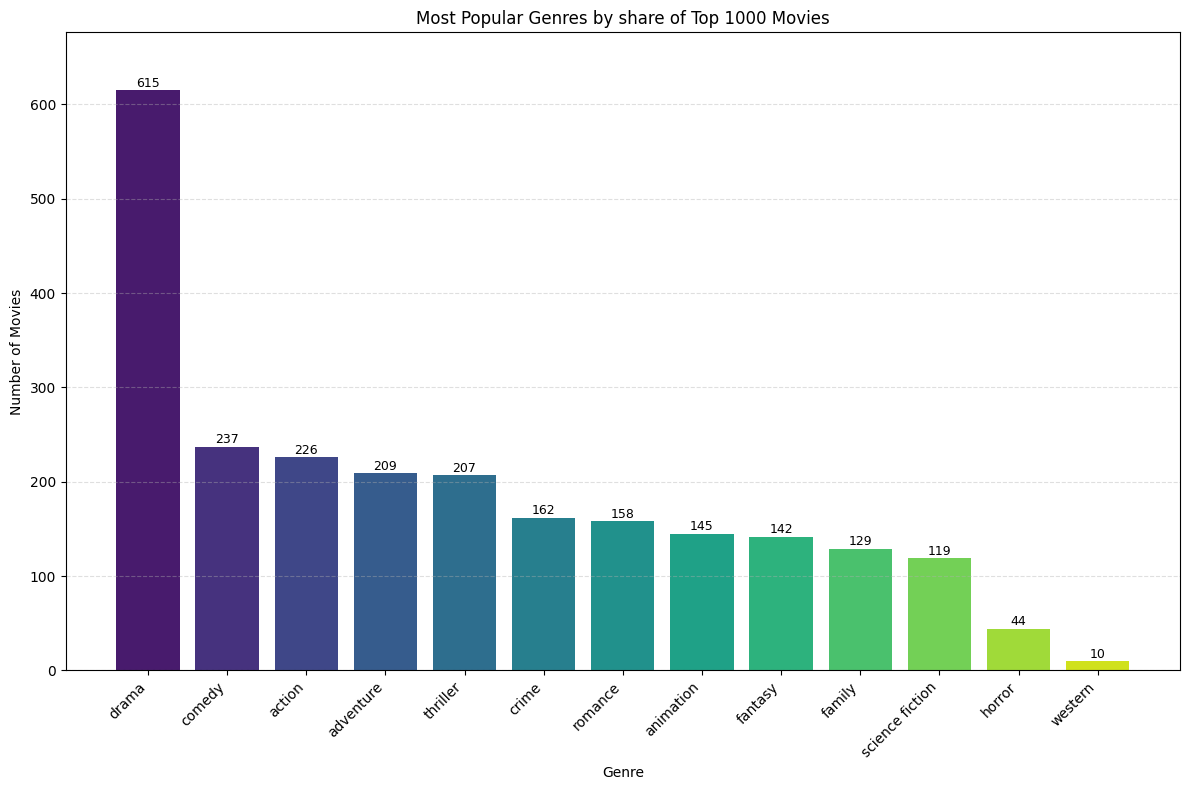

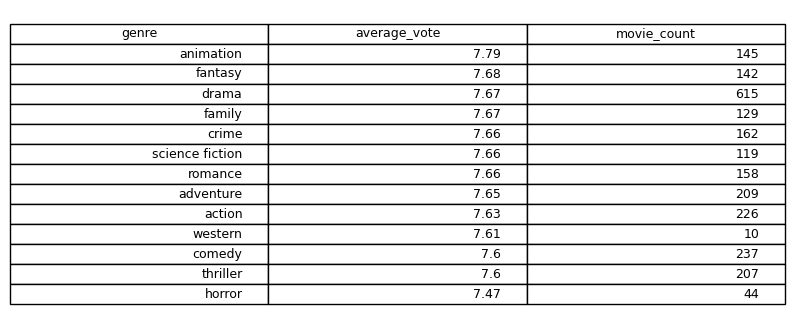

          genre  average_vote  movie_count
      animation          7.79          145
        fantasy          7.68          142
          drama          7.67          615
         family          7.67          129
          crime          7.66          162
science fiction          7.66          119
        romance          7.66          158
      adventure          7.65          209
         action          7.63          226
        western          7.61           10
         comedy          7.60          237
       thriller          7.60          207
         horror          7.47           44


In [5]:
# Most Popular Genres in Top 1000 Movies by rating
popular_genres_top_1000(df_tmdb_top_1000, save_fig=True)

**Key Insights:**
- **Drama** dominates the top-rated films, reflecting strong audience engagement with character-driven stories.
- **Comedy, action and adventure** are frequent supporting genres.
- Overall, the top genres have more or less the same average rating, but **animation appears to outperform** the rest.
- Note - **Multi-genre overlap:** Most films are tagged with multiple genres, so percentages sum to more than 100%.

##### Most Popular Production Companies in Top 1000 Movies

Which production companies are most represented among the highest-rated films? This chart shows how many films in the top 1,000 are associated with each major studio or production company. Like genres, films with multiple producers are counted for each.

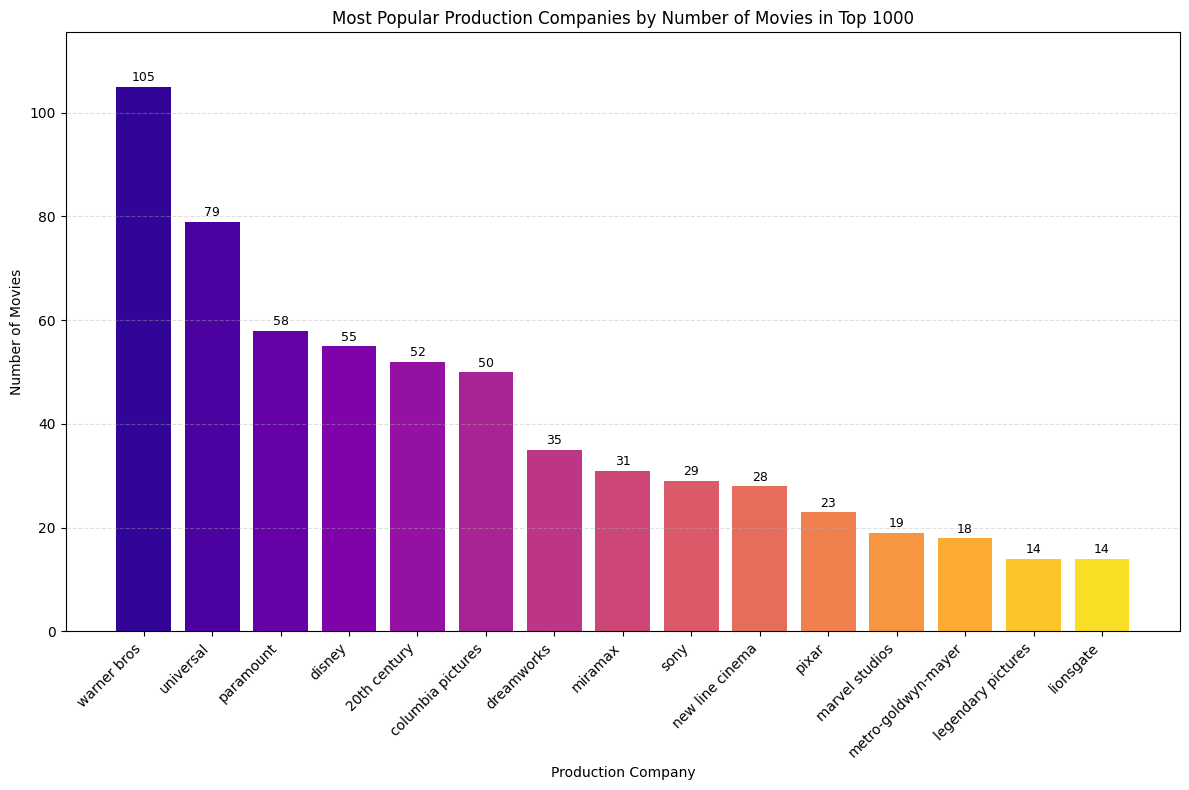

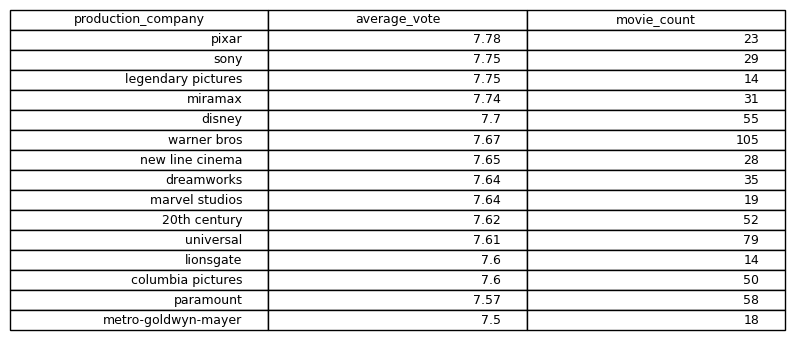

 production_company  average_vote  movie_count
              pixar          7.78           23
               sony          7.75           29
 legendary pictures          7.75           14
            miramax          7.74           31
             disney          7.70           55
        warner bros          7.67          105
    new line cinema          7.65           28
         dreamworks          7.64           35
     marvel studios          7.64           19
       20th century          7.62           52
          universal          7.61           79
          lionsgate          7.60           14
  columbia pictures          7.60           50
          paramount          7.57           58
metro-goldwyn-mayer          7.50           18


In [6]:
# Most Popular Production Companies in Top 1000 Movies
main_production_companies_top_1000(df_tmdb_top_1000, save_fig=True)

**Key Insights:**
- **Warner Bros and Universal** consistently produce films that receive high audience ratings, reflecting their experience, resources, and talent rosters.
- **Paramount**, **Disney** and **20th century** are major players in the top 1,000, indicating strong performance across multiple genres and markets.
- Overall, the top companies have similar average ratings, but the biggest studios leading in vote average are **Disney & Pixar** and **Sony**.
- **Smaller studios and independents** (e.g., Pixar, Miramax, New Line Cinema) appear less frequently overall
- Note on **Co-production prevalence:** Many top films involve multiple production companies, reflecting modern co-financing models.

##### Top-Rated Movies by Era

How do the highest-rated films differ across decades? Below, we examine the top 20 films (by vote average) within a selected time period. Modify the `start_year` and `end_year` variables to explore different eras. Films are color-coded by their primary genre.

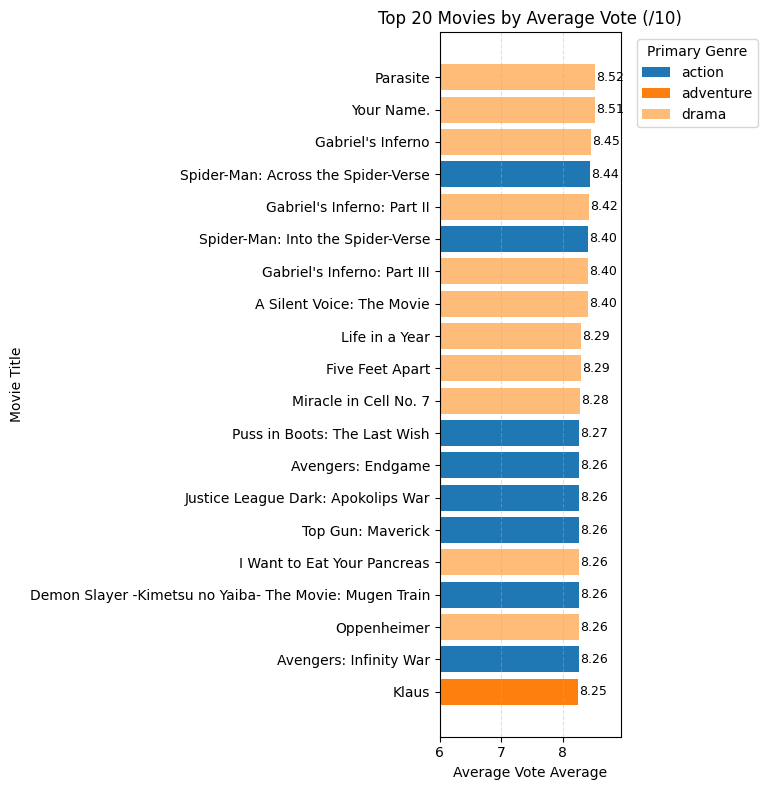

In [7]:
# SELECT TIME PERIOD for analysis - modify these to explore different eras

## Option 1: 1980-1999 (Classic era)
#start_year = 1980
#end_year = 1999

## Option 2: 2000-2014 (Digital transition)
#start_year = 2000
#end_year = 2014

## Option 3: 2015-2025 (Streaming era)
start_year = 2015
end_year = 2025

# Top 20 movie titles by average vote in the filtered df_top dataset
top20_movies_by_average_vote(df_tmdb_top_1000, start_year, end_year, save_fig=True)

**Key Insights:** What Makes a "Top" Movie?

- Earlier eras are more anchored in drama and classic storytelling, while later decades see fantasy, animation, and blockbuster franchises rising to the top. 

Major studios have the resources to consistently reach the top-rated tier, though breakthrough films from smaller companies occasionally achieve critical acclaim. Understanding these patterns helps identify what audiences globally value in cinema.

----------------

### II. Box Office - Theatrical Revenue Analysis

#### Overview

This section analyzes theatrical box office performance using data from The Numbers, focusing on the **top 100 box office-grossing films between 2015 and 2025**. Unlike the TMDb analysis (which ranks by audience ratings), this section emphasizes **financial performance**. We explore which **theatrical distributors** and **genres** dominate the market, and how box office composition has evolved across this 10-year period of streaming disruption and theatrical recovery post pandemic

#### Data

**Source:** [The Numbers - Box Office Database](https://www.the-numbers.com/market/2026/summary)

**Coverage:** Top 100 box office-grossing films (2015–2025)

**Metrics included (non-exhaustive):**
- Worldwide box office revenue
- Domestic (US) and International revenue breakdown
- Production budget
- Theatrical distributor
- Genre classification

#### Data Preparation & Methodology

For detailed information on how The Numbers dataset was loaded and cleaned, please refer to [load_data.py](../scripts/load_data.py).

**Key preparation steps:**
- **Top 100 selection:** Only the 100 highest-grossing films per year are analysed.
- **Genre categorization:** Single-genre assignment per film (unlike TMDb's multi-genre flags) for clearer trend visualization.

#### Distributor Analysis

Which theatrical distributors dominate the top-grossing films? The charts below show how the major distributors' presence in the top 100 has evolved from 2015 to 2025, and their total box office contribution.

##### **Movies in Top 100 by Distributor (Over Time)**

How has distributor market concentration changed? This stacked bar chart shows the count of top 100 films per distributor for each year. Larger segments indicate stronger representation in the highest-grossing tier.

**Selection note (movies-by-distributor):** The chart below displays the top 8 distributors chosen by the number of films they have in the Top 100

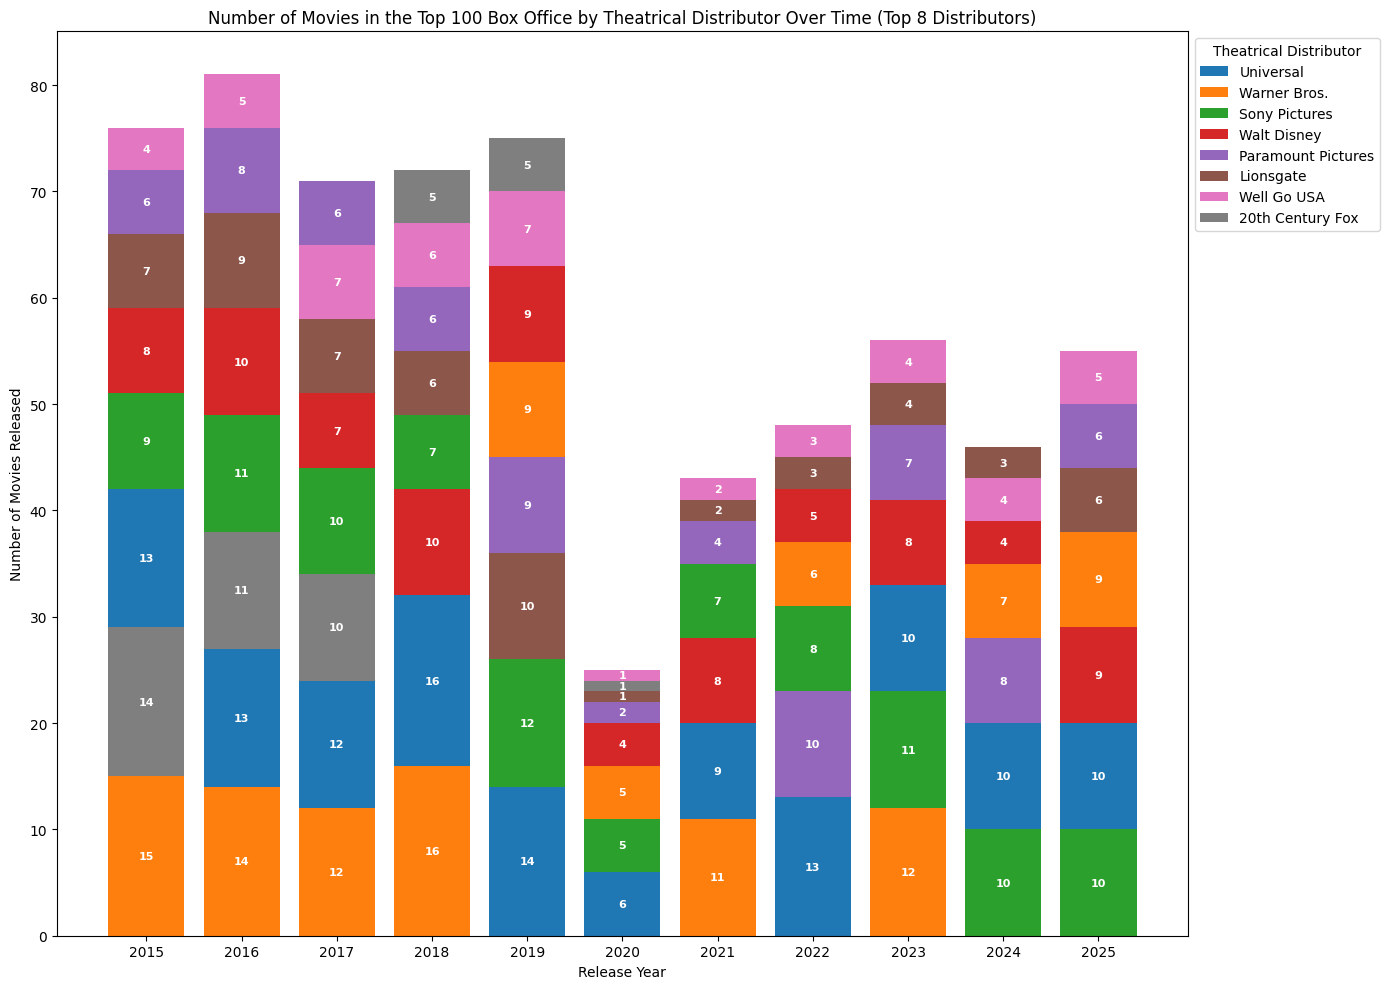

In [8]:
# Count of movies per theatrical distributor per year - top 8 distributors
movie_count_per_distributor_overtime_top8(df_the_numbers, save_fig=True)

**Key Insights:**
- **Major studios (Disney, Warner Bros, Universal, Paramount, Sony)** consistently occupy most of the top 100 slots.
- Note: **20th Century Fox**'s contribution drops from 2019 after being acquired by **Disney's**, whose dominance also grew with Marvel and Star Wars franchises.
- **Independent and mid-tier distributors** occasionally break into the top 100 with mega-hits, but rarely sustain multiple entries per year.
- **Market consolidation:** The top 5-8 distributors account for the vast majority of top-grossing films, indicating high barriers to entry.

##### **Worldwide Box Office Revenue by Distributor (Trend)**

Which distributors drive the largest revenues? This line chart tracks the total worldwide box office revenue for the top 5 distributors across 2015–2025.

**Selection note (revenue-trend):** The revenue trend chart selects the top 5 distributors by summing the `Worldwide Box Office` column across the dataset and taking the highest totals (so distributors here are chosen by total revenue, not by movie count).

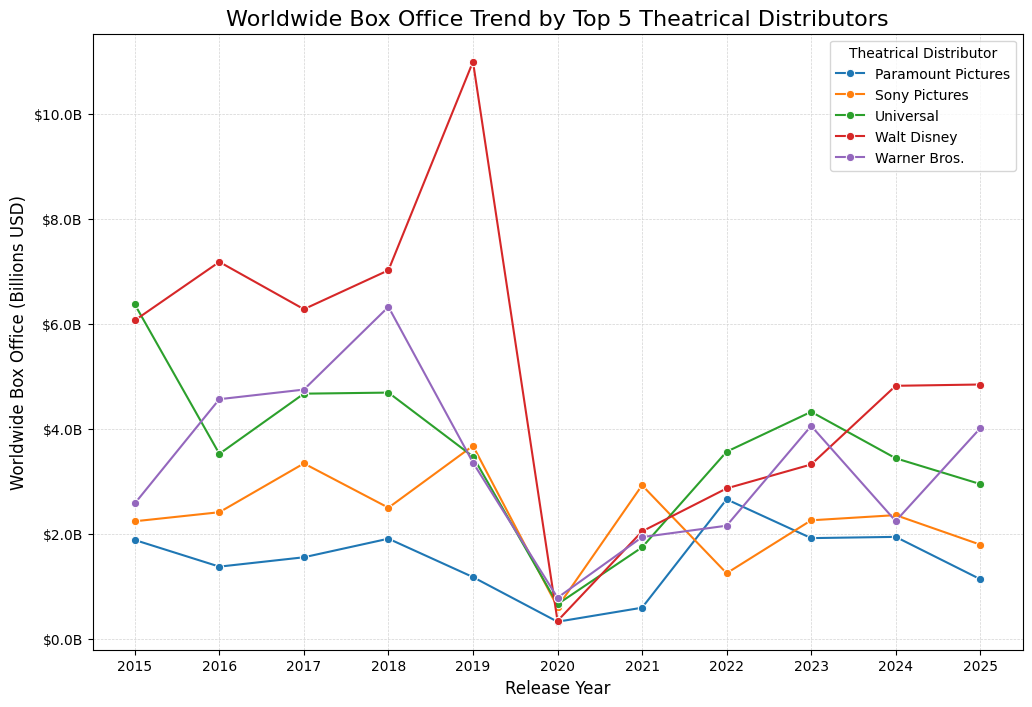

In [9]:
# Worldwide Box Office Revenue Trend by Distributor
worldwide_box_office_trend_by_distributor(df_the_numbers, save_fig=True)

**Key Insights:**
- The top distributors show clear recovery after the COVID downturn, with 2022 onward returning to pre-pandemic volume and revenue growth.
- Revenue leadership is concentrated among a consistent core of studios, with only a few distributors maintaining the bulk of box office returns each year.
- Volatility is more pronounced post pandemic, with the exception of Disney on a consistently upward trend.

#### Genre Analysis

Which genres are most profitable at the box office? Unlike ratings-based analysis, box office success reflects a mix of audience appeal, marketing spend, and franchise loyalty.

##### **Worldwide Box Office by Genre (Trend)**

How have different genres performed financially across the decade? This line chart tracks the total worldwide box office revenue for the top 5 genres from 2015 to 2025.

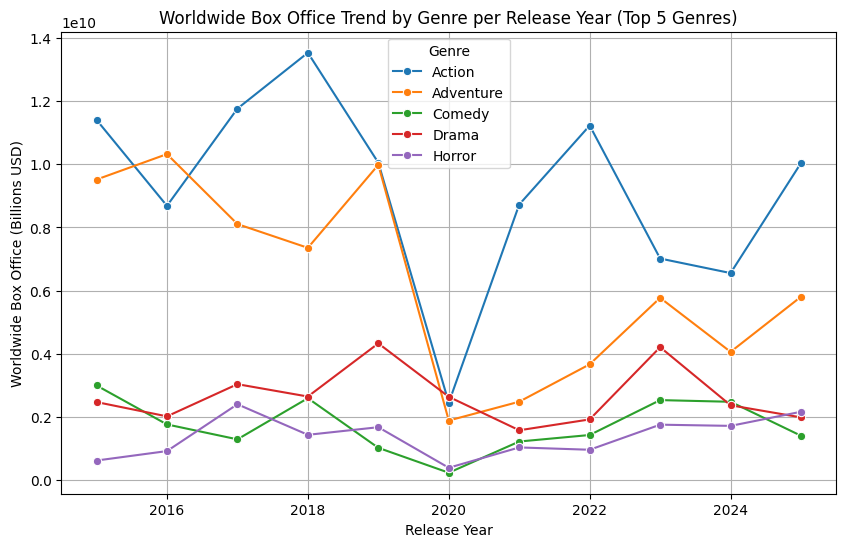

In [10]:
# Worldwide Box Office Revenue Trend by Genre
worldwide_box_office_trend_by_genre(df_the_numbers, save_fig=True)

**Key Insights:**
- **Action and adventure** consistently generate the highest revenues, driven by big-budget franchises and visual spectacles.
- **Comedy** has struggled post-2015, with lower representation in top-grossing films.
- **Genre concentration:** Top 100 films tend to cluster in a few genre categories, with niche genres not making it into the shortlist.
- **Drama** show relative volatility, and **Horror** is worth noting as a smaller genre that consistently performs in the box office.

##### **Genre Distribution Over Time (Top 5 Genres)**

What percentage of top 100 films belong to each genre? This stacked bar chart shows the year-by-year composition of the top 5 genres.

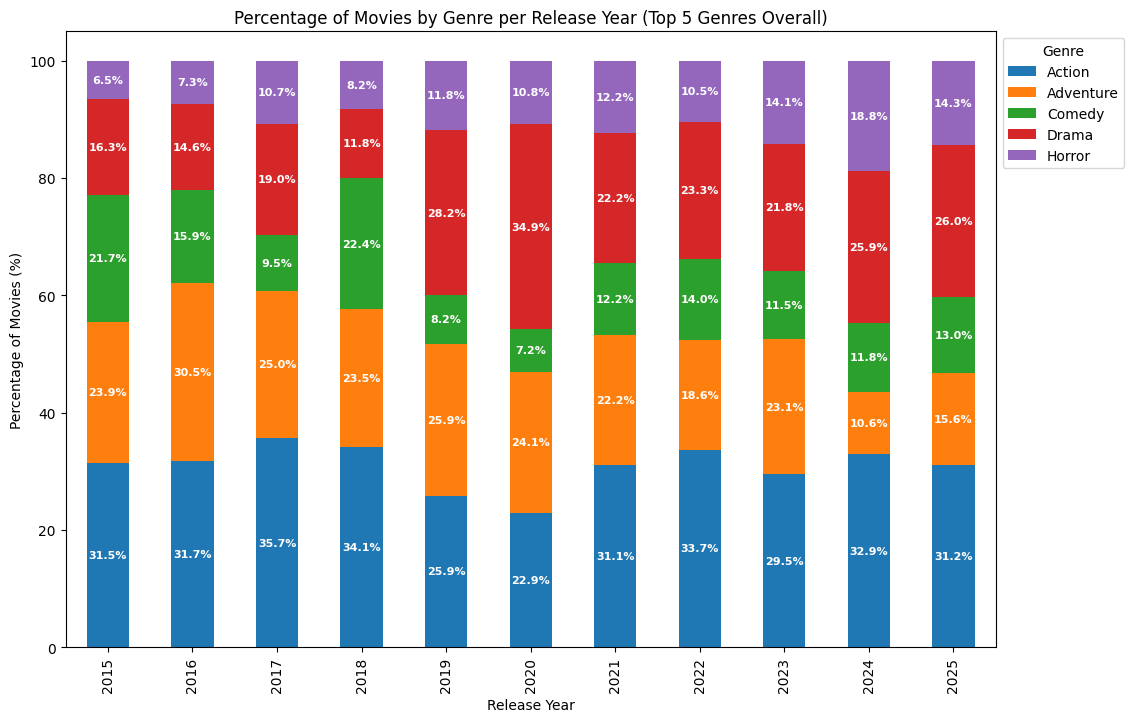

In [ ]:
# Top 5 Genres Percentage Distribution per Year
top_5_genres_percentage_per_year(df_the_numbers, save_fig=True)

##### **Genre Distribution Over Time (Top 8 Genres)**

What happens when we expand to the top 8 genres? This stacked bar chart reveals more granular trends and shows whether other genres have gained traction.

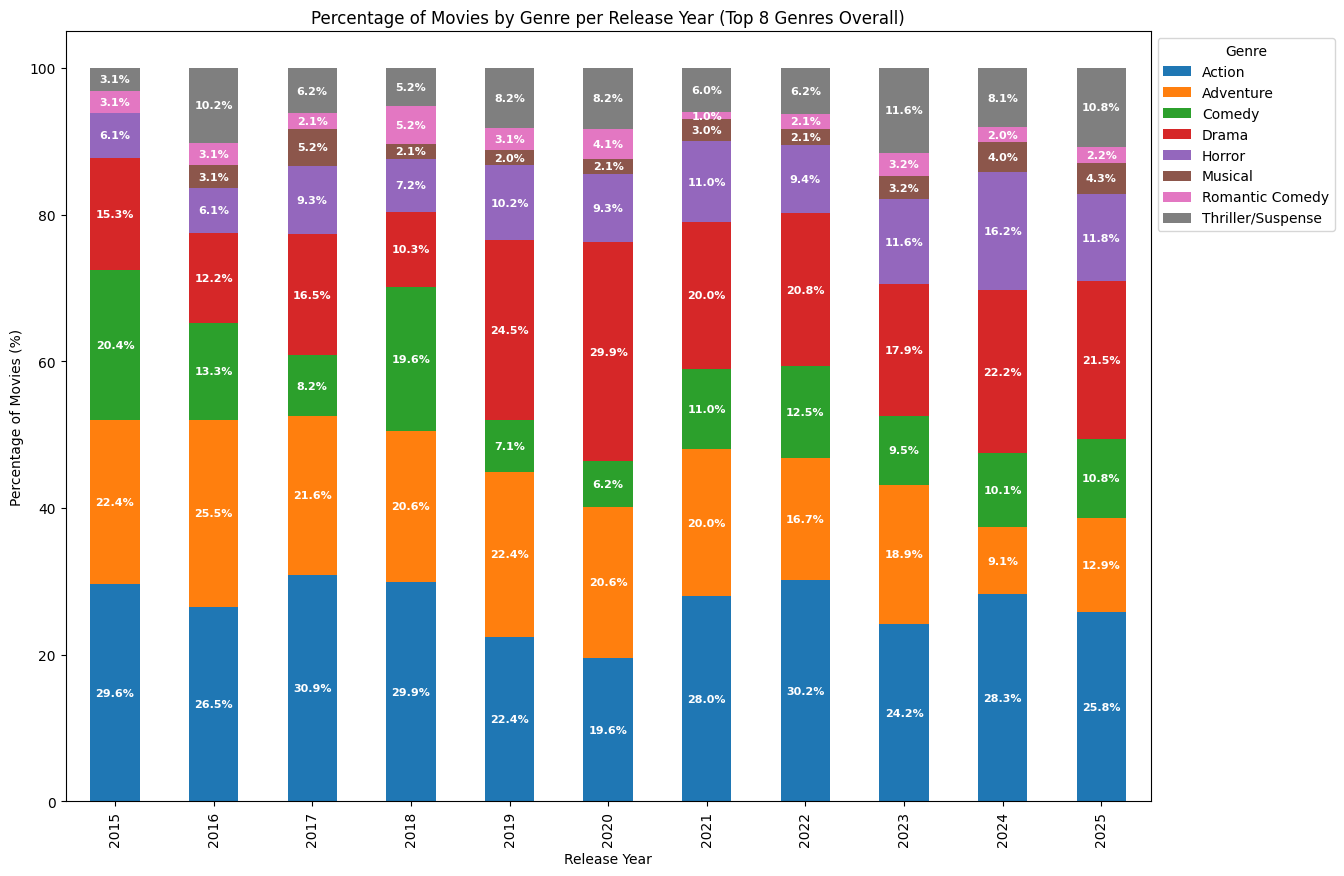

In [ ]:
# Top 8 Genres Percentage Distribution per Year
top_8_genres_percentage_per_year(df_the_numbers, save_fig=True)

**Key Insights:**
- **Dominance:** Action and Adventure dominate the share of global box office revenue.
- **COVID impact:** Did genre composition change slighly in 2020–2021 with a bigger share of the box office going to Drama instead of Adventure and Action.
- **Smaller Genres:** Looking at the top 8, Thrillers make up an important and consistent share of the box office, with Romantic Comedy and Musicals having a much smaller representation.

**Caveat:** These percentages reflect only the top 5 and 8 genres in the dataset. Less common genres in the top 100 include: western, documentary and reality. 

#### Summary: What Drives Box Office Success?

Theaters are dominated by big-budget, action-driven films from major studios. Blockbuster franchises (Marvel, Star Wars) command significant audience turnout in theatres. While diverse genres occasionally break through with critical hits, financial success at the box office correlates strongly with franchise recognition, visual spectacle, and wide distribution - factors favoring major studios over independents. In the 2015–2025 period streaming competition has reshaped theatrical strategies toward event films rather than mid-budget releases.

----------------

## III. Awards - The Oscars

### Overview

This section analyzes Oscar winners from 1980 to 2024 to identify long-term trends in the Academy Awards. The analysis explores which **genres** and **production companies** have achieved the most Oscar success, and whether these patterns have shifted over decades. All analysis focuses on **winners only** to understand what characteristics define Academy-recognized films.

### Data

**Source:** [Kaggle - The Oscar Award Dataset](https://www.kaggle.com/datasets/unanimad/the-oscar-award/data)

**Coverage:** Oscar ceremonies from 1980 to 2024 (1927–2024 data available; filtered to 1980 onward for more recent trends)

**Integration:** Oscar winners are matched to TMDb metadata for enrichment (genres, production companies, and vote averages). Only records with a successful match (`_merge == 'both'`) are included in this analysis.

### Data Preparation & Methodology

For detailed information on how the Oscar and TMDb datasets were loaded, cleaned, and merged, please refer to [load_data.py](../scripts/load_data.py).

**Key preparation steps:**
- **Genres and Production Companies:** Converted to binary flag columns (0 or 1) so a single film can contribute to multiple genres or companies. This enables multi-genre and multi-company analysis.
- **Decades:** Grouped as 1980–1989, 1990–1999, 2000–2009, 2010–2019, 2020–2024.
- **Filtering:** Only Oscar winners (not nominees) are included to focus on Academy-recognized excellence.

### Winners by Year

Below is a detailed table of Oscar winners for a selected year. You can modify the `year` variable to explore winners from different ceremonies. The table includes the winning film's category, title, lead winner's name, production companies, genres, and TMDb average vote rating.

In [13]:
# Winners per year

year = 2020 # Select a year

df = df_oscar_tmdb.copy()

winners = oscars_winners(df,year)
oscars_winners_table(winners, year, save_fig=True)

WARNING	Property: Unknown Property name. [26:3: word-wrap]


Category,Film,Winner,Production Companies,Genre,TMDb Average Vote
ACTOR IN A LEADING ROLE,The Father,Anthony Hopkins,"Trademark Films, F Comme Film, Ciné-@, Embankment Films, Film4 Productions, Canal+, Ciné+, Orange Studio, Les Films du Cru, AG Studios NYC, Simon Friend Entertainment, Viewfinder, CAA Media Finance, Sony Pictures Classics",Drama,8.15
ACTOR IN A SUPPORTING ROLE,Judas and the Black Messiah,Daniel Kaluuya,"MACRO, Bron Studios, Participant, Proximity Media, Warner Bros. Pictures","Drama, History",7.36
ACTRESS IN A LEADING ROLE,Nomadland,Frances McDormand,"Cor Cordium Productions, Hear/Say Productions, Highwayman Films",Drama,7.24
ACTRESS IN A SUPPORTING ROLE,Minari,Yuh-Jung Youn,Plan B Entertainment,Drama,7.36
ANIMATED FEATURE FILM,Soul,Pete Docter and Dana Murray,"Walt Disney Pictures, Pixar","Animation, Family, Comedy, Fantasy, Drama",8.15
ART DIRECTION,Mank,Production Design: Donald Graham Burt; Set Decoration: Jan Pascale,Netflix International Pictures,"Drama, History",6.73
BEST PICTURE,Nomadland,"Frances McDormand, Peter Spears, Mollye Asher, Dan Janvey and Chloé Zhao, Producers","Cor Cordium Productions, Hear/Say Productions, Highwayman Films",Drama,7.24
CINEMATOGRAPHY,Mank,Erik Messerschmidt,Netflix International Pictures,"Drama, History",6.73
COSTUME DESIGN,Ma Rainey's Black Bottom,Ann Roth,"Escape Artists, Mundy Lane Entertainment","Drama, Music",6.68
DIRECTING,Nomadland,Chloé Zhao,"Cor Cordium Productions, Hear/Say Productions, Highwayman Films",Drama,7.24


### Genre Analysis

#### **Total Oscar Wins by Genre (1980–2024)**

Which genres win the most Oscars? The chart below aggregates all Oscar wins by genre across the entire 45-year period. 

**Note** that films with multiple genres contribute to each genre count, so overlaps are expected—a drama-thriller will be counted in both categories.

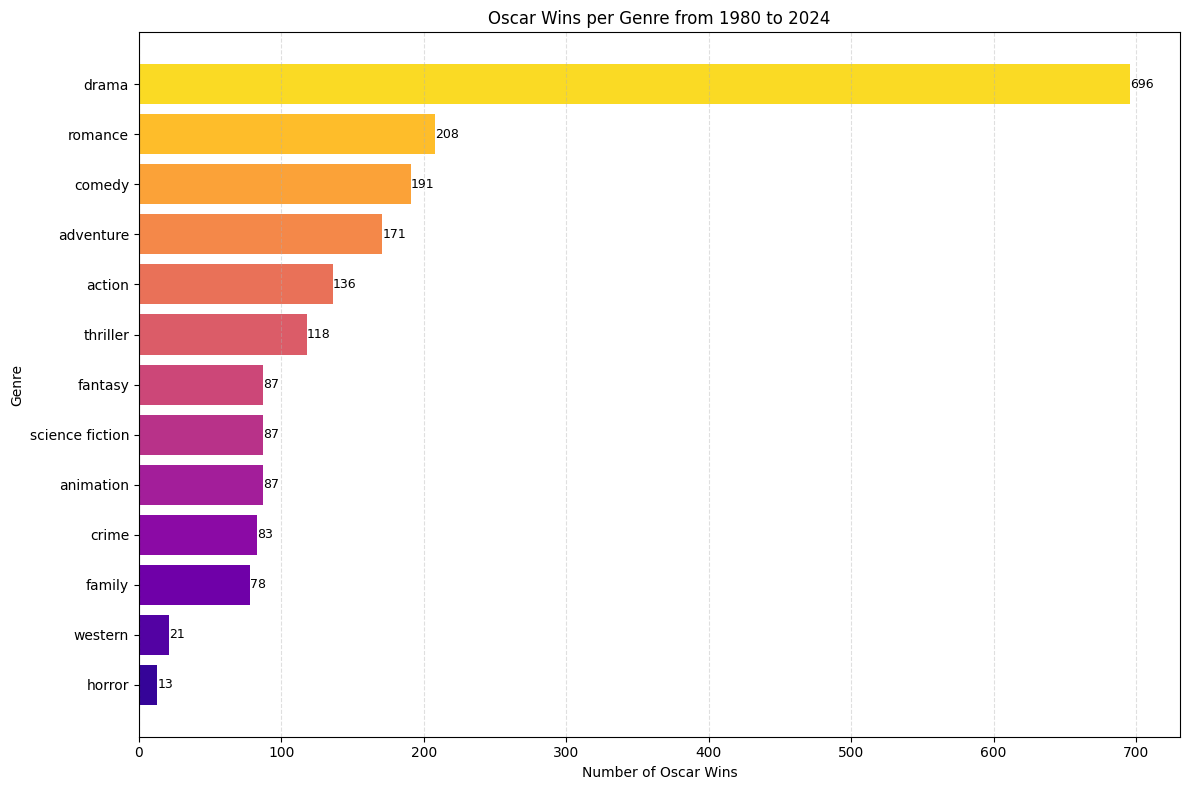

In [14]:
# Genres with the most wins

df = df_oscar_tmdb.copy()
total_oscar_wins_per_genre(df, save_fig=True)

**Key Insights:**
- **Drama** is the dominant genre in Oscar history, reflecting the Academy's traditional preference for character-driven narratives.
- **Comedy, Romance and Adventure** follow and also appear frequently
- **Science fiction and Fantasy**, while growing in recognition, remain less common in major Oscar wins compared to drama.

Note: **Multi-genre overlap**  - A film tagged as both drama and romance is counted in both bars, so the sum exceeds the total number of winners.

#### **Genre Trends Over Decades**

Has genre popularity in the Oscars shifted over time? The chart below shows the **top 4 genres per decade**, allowing us to compare whether drama's dominance has changed, or if other genres have gained ground.

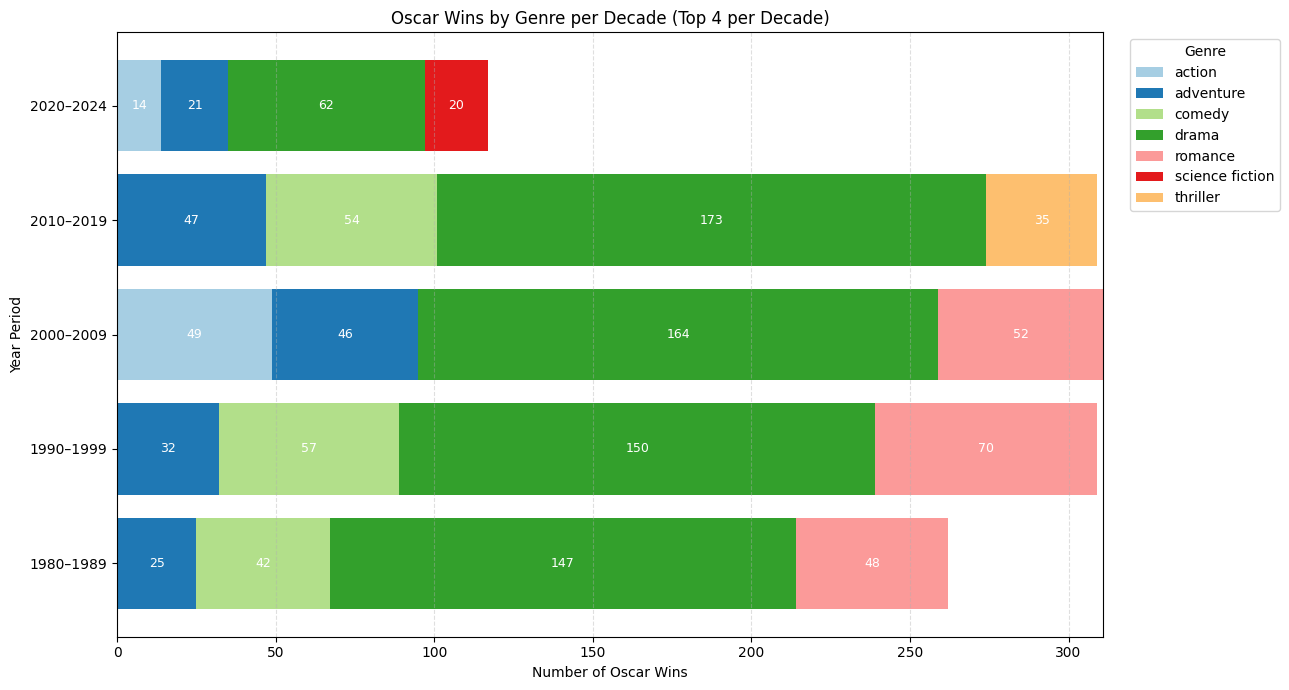

In [ ]:
# Genres with the most wins per Decade

df = df_oscar_tmdb.copy()
oscar_wins_top_genres_per_decade(df,top_n=4, save_fig=True)

**Key Insights:**

- **Drama** remains consistently dominant across all decades, indicating a sustained Academy preference for serious, character-driven storytelling.
- **Romance** has declined significantly over time and disappears from the top genres after the 2000s, suggesting a shift away from traditional romantic narratives.
- New genres such as **Thriller** (2010s) and **Science Fiction** (2020–2024) emerge in later decades, highlighting a gradual broadening of what is considered award-worthy cinema.
- **Comedy and Adventure** remain present across most decades but fluctuate in prominence.
- Shifts in Academy tastes: Overall, the Academy’s genre preferences have evolved from a concentrated mix toward greater diversity, with a wider range of storytelling styles gaining recognition over time.

**Note:** The 2020–2024 period is weighted toward recent years, so patterns may differ from longer decades.

### Production Company Analysis

**Note**: The analysis includes only the top production companies ranked by total Oscar wins. Companies with a smaller number of wins have been excluded to ensure clarity and focus on the most impactful contributors.

#### **Total Oscar Wins by Production Company (1980–2024)**

Which production companies have built the strongest track record with the Academy? This chart ranks the major production studios and independents by total Oscar wins across the 45-year period. 
**Note:** Like genres, a film with multiple production companies is counted for each.

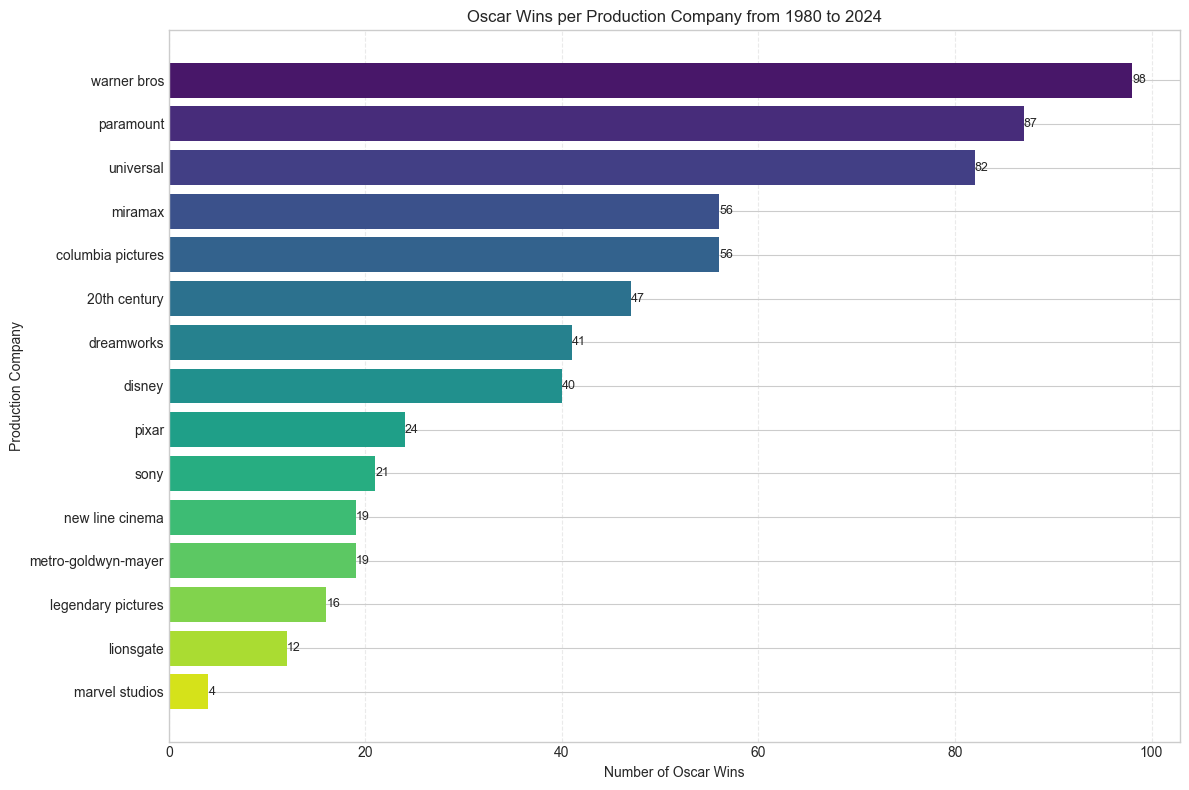

In [ ]:
# Production Companies with the most wins

df = df_oscar_tmdb.copy()

total_oscar_wins_per_production_company(df, save_fig=True)

**Key Insights:**
- Warner Bros, Paramount, and Universal clearly dominate Oscar wins, forming a top tier with a clear gap to all other studios.
- There is a sharp drop-off after the top three, with mid-tier studios such as Miramax and Columbia Pictures (~56 wins each) contributing meaningfully but at a lower level.
- Miramax stands out among non-major studios, outperforming several traditional big studios and highlighting the impact of awards-focused production strategies.
- Disney, DreamWorks, and 20th Century form a competitive middle group, showing consistent but not leading Oscar performance despite their scale.

Overall, Oscar success is highly concentrated among a few studios, with a long tail of smaller or more specialised companies contributing fewer wins.

Note - **Multi-company attribution:** If a film is co-produced by multiple studios, each is credited with a win.

#### **Production Company Trends Over Decades**

Have the same studios dominated across all decades, or have new companies entered the Oscar arena? This chart shows the **top 4 production companies per decade**.

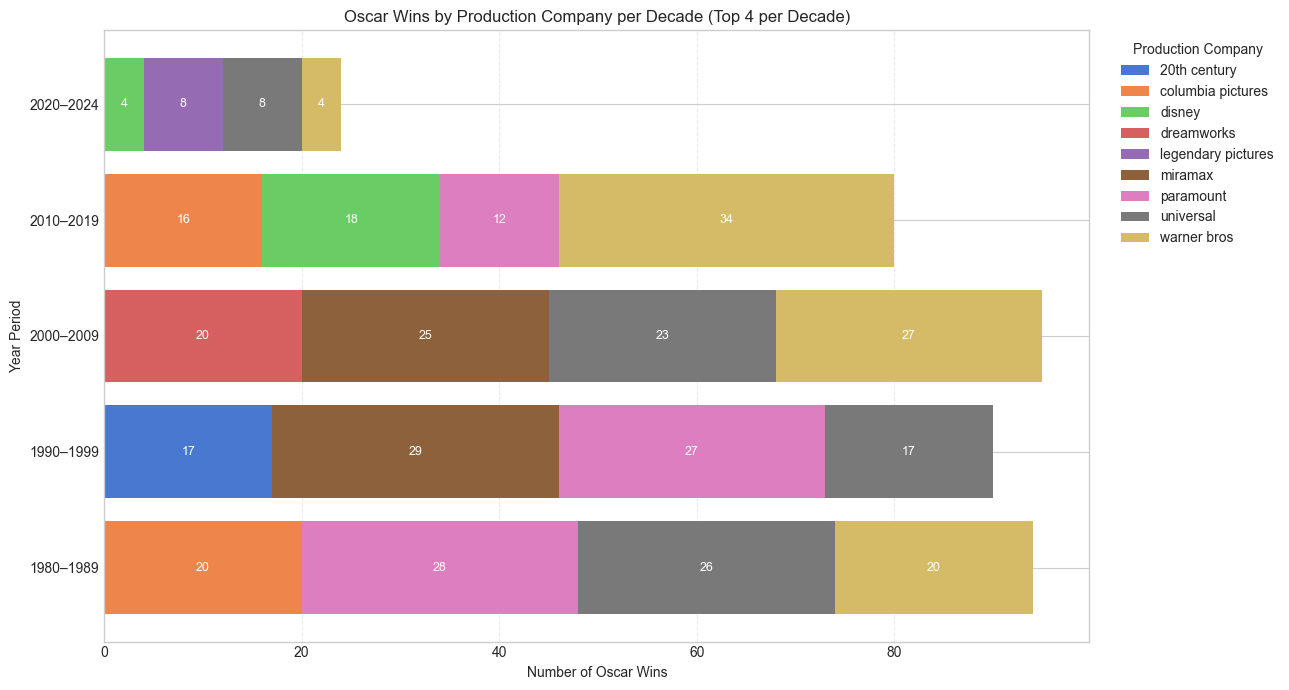

In [ ]:
# Production Companies with the most wins per Decade

df = df_oscar_tmdb.copy()

oscar_wins_top_companies_per_decade(df,top_n=4, save_fig=True)

**Key Insights:**
- No single studio dominates consistently across all decades, with leadership shifting between different companies over time.
- Warner Bros is the most consistently high-performing studio, appearing in multiple decades and leading strongly in both the 2000s (27 wins) and 2010s (34 wins).
- The 1990s and 2000s are more concentrated, with a smaller group of studios (e.g. Miramax, Paramount, Universal) accounting for a large share of wins, indicating stronger period-specific dominance.
- The 2010s show a shift toward a more diverse set of leading studios, with Disney and Columbia Pictures emerging alongside Warner Bros, suggesting a broadening competitive field.
- Recent years (2020–2024) reflect disruption and lower concentration, with no clear leader and relatively even win distribution among the top studios.

### Summary: What Oscar Winners Tell Us

**Genre patterns:** Drama remains the Academy's backbone, but supporting genres (comedy, romance, adventure) have maintained steady presence. The rise of animation and science fiction in recent decades suggests slow but measurable diversification.

**Production company patterns:** The major studios (Warner Bros, Paramount, Universal, Disney) are built to succeed with the Academy, backed by resources, talent, and distribution reach. Yet the top-4 composition per decade hints that new players do emerge, often bringing fresh voices and perspectives.

**Implications:** Understanding what wins Oscars - across genres and studios - offers insight into Academy values, industry economics, and audience tastes reflected in award bodies.

----------

## IV. Netflix - Streaming Success Metrics

#### Overview

This section analyzes Netflix's evolution from 2013 to 2025 across three critical dimensions: **financial performance** (revenue and spending), **subscriber growth**, and **content engagement** (most-watched movies and shows). Together, these metrics reveal Netflix's strategy: investing heavily in content to drive subscriber acquisition and retention, and tracking audience engagement to understand what content resonates globally. This analysis provides insight into the streaming industry's economic model and content preferences.

#### Data

**Sources:**
- **Revenue & Subscribers:** [Backlinko - Netflix Statistics](https://backlinko.com/netflix-users)
- **Content Spending:** Netflix annual reports and financial disclosures
- **Content Engagement:** [Netflix Top 10 Report](https://www.whats-on-netflix.com/most-popular/netflix-engagement-report-search/) and Netflix Engagement Report

**Coverage:**
- **Revenue & Subscribers:** 2001–2024
- **Content Spending:** 2013–2024
- **Engagement Data:** 2023–2025 (recent top movies and shows by hours viewed and total views)

#### Data Preparation & Methodology

For detailed information on how Netflix datasets were loaded and cleaned, please refer to [load_data.py](../scripts/load_data.py).

**Key preparation steps:**
- **Currency normalization:** All financial figures are in USD for consistency.
- **Engagement ranking:** Movies and shows are ranked by total hours viewed and total views, providing two perspectives on success (binge-ability vs. broad appeal).
- **Content type separation:** Movies and TV shows are analyzed separately due to different engagement patterns.

#### Financial & Subscriber Growth

##### **Revenue and Subscribers Over Time**

How have Netflix's financial performance and subscriber base grown? This dual-axis chart shows revenue (blue line, left axis) and global subscribers (red line, right axis) from 2001 to 2023.

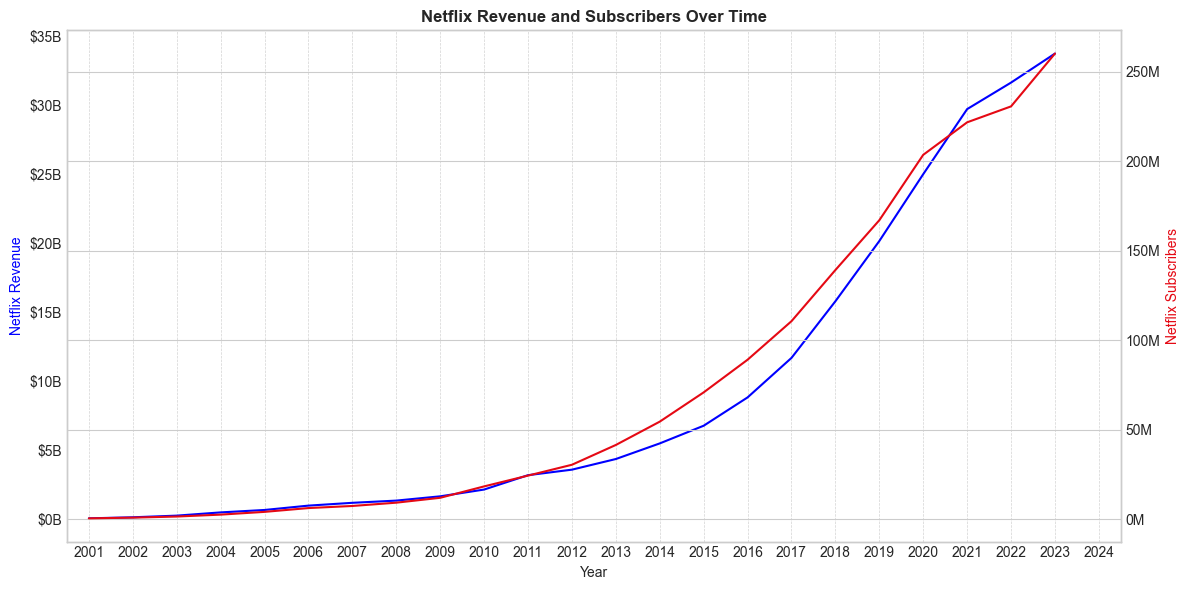

In [18]:
# Netflix Revenue and Subscriber Growth Over Time
netflix_rev_subs(df_netflix_revenue_subs_spend, save_fig=True)

**Key Insights:**
- **Revenue and subscriber growth** track closely over time, suggesting a strong positive relationship between audience expansion and revenue scaling.
- **Growth accelerates significantly from the mid-2010s** onwards, with both subscribers and revenue increasing much faster than in earlier years.
- **Economy impact** : The 2020–2021 period shows a clear spike in both metrics, likely associated with the pandemic-driven surge in streaming demand, which stands out from the longer-term trend.

Overall, Netflix demonstrates a shift from rapid user acquisition toward sustained revenue growth, with expansion becoming more gradual in recent years.

##### **Content Spending Over Time**

How much has Netflix invested in content? Content spending is the engine of Netflix's strategy—higher budgets fund better content, which drives subscriber acquisition and retention.

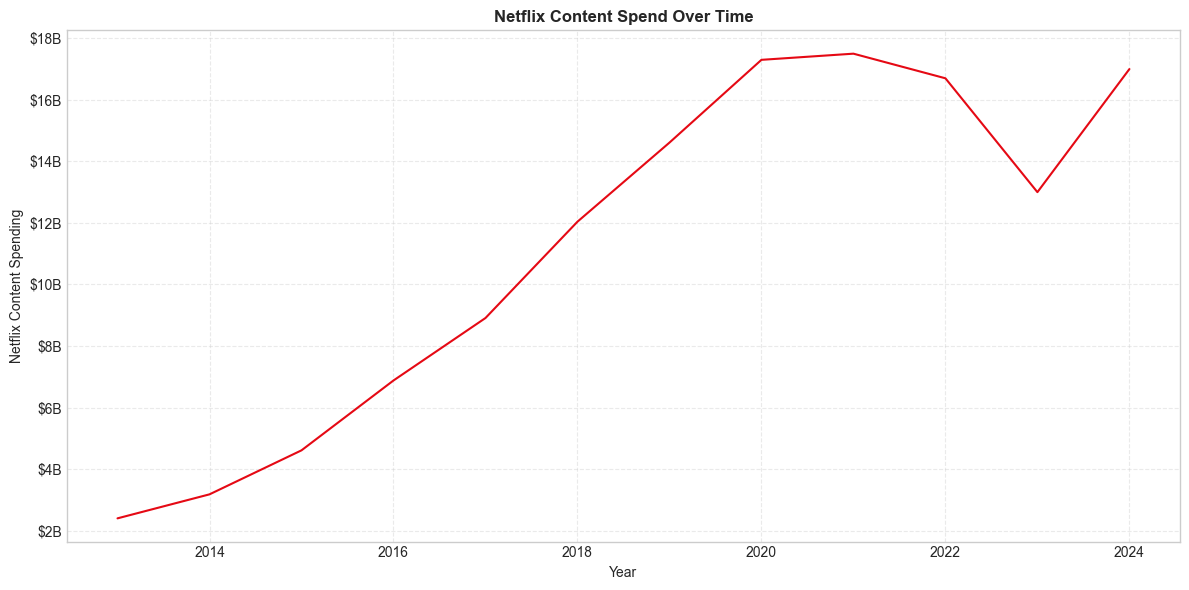

In [19]:
# Netflix Content Spending Over Time
netflix_spend(df_netflix_revenue_subs_spend, save_fig=True)

**Key Insights:**
- **Exponential growth:** Content spending increases sharply from 2013 to 2020, rising from roughly ~$2–3B to over $17B, indicating a period of rapid expansion and investment.
- **Spend acceleration:** The fastest growth occurs between 2016 and 2020, where spending accelerates significantly year-on-year, coinciding with major original series launches (Stranger Things, The Crown, Bridgerton).
- **Spending appears to plateau around 2020–2022**, stabilising in the ~$16–18B range after the earlier period of rapid growth, despite revenue increases. **A dip is visible in 2023 followed by a rebound in 2024**, suggesting some short-term fluctuation after a period of sustained high investment.


**Competitive context:** Major streaming platforms such as Amazon Prime Video (early 2010s), Disney+ (2019), and HBO Max (2020) entered or expanded during this period, broadly overlapping with Netflix’s peak spending years.

**Content strategy shift:** The rise in spending aligns with Netflix’s transition from licensed content toward greater investment in original programming, reflecting a shift toward ownership and long-term content control.


#### Content Engagement Analysis

##### **Top 10 Movies by Engagement (2023–2025)**

Which movies have driven the most engagement? Two metrics reveal different success dimensions: **total hours viewed** and **total views**.

**What to look for:**
- **Hours viewed:** Indicates films that keep audiences engaged. Often longer movies or repeat watchers.
- **Total views:** Shows wide appeal and discoverability. Often event films or franchise entries.

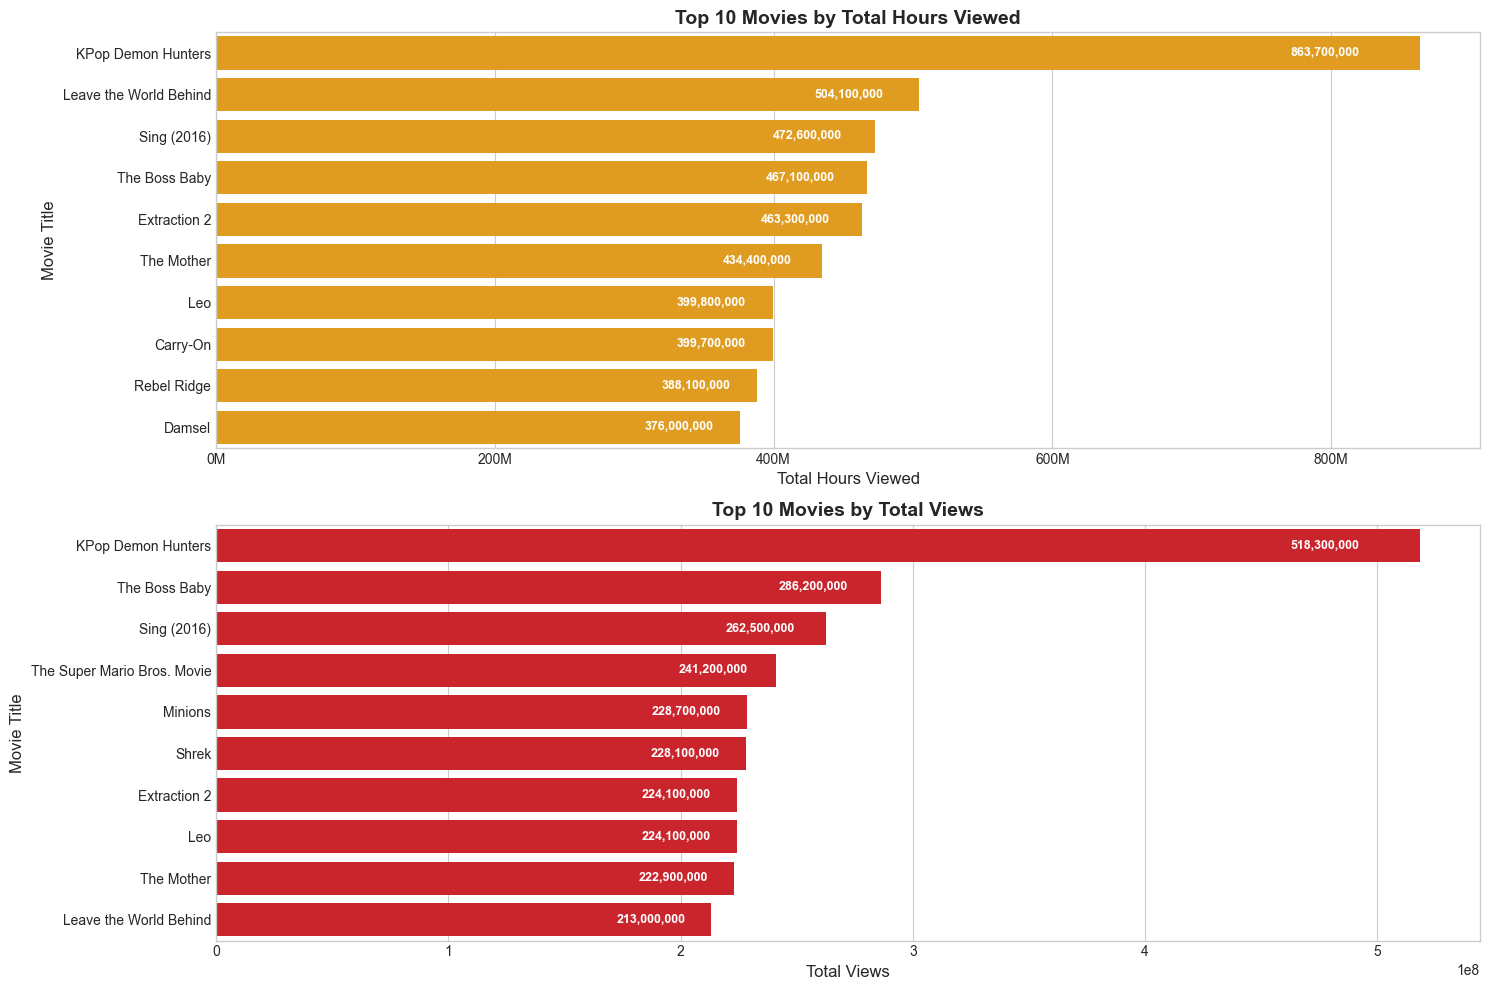

In [20]:
# Top 10 Movies by Engagement (2023-2025)
netflix_top_movies(df_netflix_engagement, save_fig=True)

**Key Insights:**
- A single title **(“KPop Demon Hunters”) clearly dominates** both hours viewed (~864M) and total views (~518M), indicating exceptionally strong engagement as well as broad reach compared to all other films.
- **Animation and family genres** dominate the “total views” ranking, with titles such as Sing, The Boss Baby, Minions, and Shrek (all animated comedy/family films) achieving very high reach, indicating broad, cross-demographic appeal and strong discoverability.
- High-performing titles are heavily concentrated in **action and thriller genres**, with films such as Extraction 2 and The Mother classified as action-thrillers, and Leave the World Behind as a psychological/apocalyptic thriller, suggesting strong audience appetite for high-intensity, plot-driven content.
- Differences between the two rankings highlight variation in viewing behaviour, with some films ranking higher in hours than in views (or vice versa), suggesting differences in factors such as runtime, rewatchability, or depth of engagement.

##### **Top 10 Shows by Engagement (2023–2025)**

How do TV shows compare to movies in engagement? Shows often drive higher total hours viewed (due to multiple episodes) but may have lower total view counts (smaller audience for niche shows).

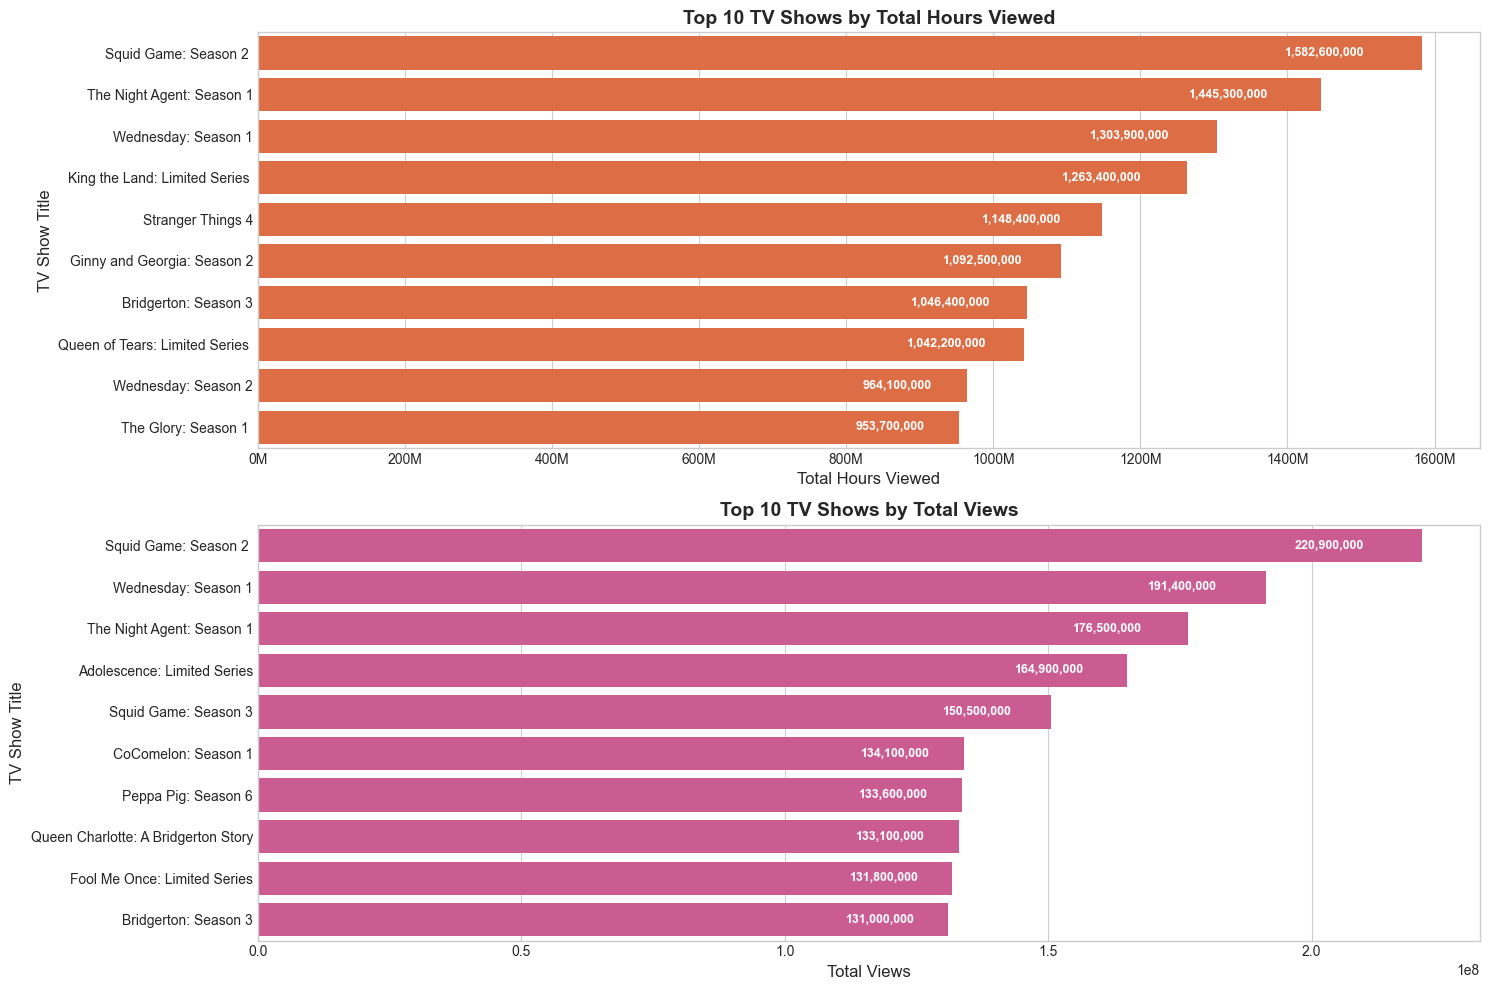

In [21]:
# Top 10 Shows by Engagement (2023-2025)
netflix_top_shows(df_netflix_engagement, save_fig=True)

**Key Insights:**
- **TV shows clearly dominate total hours viewed at a much larger scale than films**, with all top titles exceeding ~950M hours and the leader (Squid Game: Season 2) reaching ~1.6B, highlighting the strong engagement power of serialized content.
- **Franchise loyalty:** Franchise and returning seasons are heavily represented, including Squid Game (S2 & S3), Stranger Things 4, Bridgerton S3, and Wednesday S2, suggesting that established series drive sustained audience engagement.
- **Global vs. regional:** Both global and regional titles perform strongly, with non-English shows such as Squid Game, The Glory, and King the Land appearing alongside US-based series, reflecting Netflix’s increasingly international audience base.
- Differences between hours viewed and total views suggest varying engagement depth, with some series ranking highly in hours but differently in views, indicating differences in binge behaviour, episode length, or series format.


#### Summary: Netflix's Streaming Model

Netflix’s model combines sustained content investment with a focus on engagement, supported by strong long-term growth in subscribers and revenue. While subscriber growth has become more gradual in recent years, revenue continues to grow strongly alongside it. High-engagement content, particularly serialized TV shows, drives retention and platform value, while films balance action-driven engagement with broad family appeal. This is reflected in content spending, which rose sharply before stabilising at a high level, suggesting a more mature investment phase.

---------